In [1]:
import sys; sys.path.insert(0, ".")
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
from constants import (
    result_path,
    plot_path,
)
from decomposition import (
    align_oos_to_realization,
    build_benchmark_portfolios,
    build_rg_factors,
    rg_stocks_summary,
    summarize_and_plot_rg_lnf,
    build_rg_lnf_perf_stats,
    build_conditional_stats,
    print_latex_rg_lnf_perf_table,
)
from spanning import (
    prepare_insample_spanning_df,
    run_traditional_spanning,
    compare_capm_spanning,
    compare_ff6_spanning,
)
from analysis_utils import (
    load_port_analysis_data,
    get_fRet30_all,
    stargazer_with_tstats,
)


In [2]:
# Load data and PCA results
data = load_port_analysis_data()
hf_data = get_fRet30_all(data["crsp_taq"])

pca_df = pd.read_csv(Path(result_path) / "monthly_pcas.csv",
                     usecols=["YM", "permno", "news_proxy"]
                     ).rename(columns={"YM": "ym"})


In [3]:
# Monthly portfolio panel.
# All portfolios (vwMKT, BetaFP_D1, BetaFP_D10, Rg, MKTg, LNF) share the same universe
# = HF ∩ BetaFP non-NaN (set in get_fRet30_all).
#   1. benchmarks (vwMKT, BetaFP_D1, BetaFP_D10) — independent of Rg.
#   2. Rg / MKTg / LNF per month:
#      news_proxy (monthly PCA of S&P 500; pca.run_monthly_analysis) →
#      Rg0 = EW bottom 1/PCA_GLOBAL_FACTOR_FOLD of (S&P 500 ∩ HF universe).
#      → lnf_exposure_proxy_i = |γ̂(stock_i, L)|, L = vwMKT − κ·φ·Rg0.
#        κ < 1 shrinks because Rg0 is a noisy initial proxy for g.
#      → Rg = VW bottom 1/RG_SELECT_FOLD of HF universe by proxy.
#      → φ = robust projection of vwMKT on Rg (HF, for SNR); φ is the Rg portfolio weight.
#        MKTg = φ·Rg, LNF = vwMKT − MKTg.
#   3. align OOS columns to realization month (display-only transform).
bench_wt, bench_ret = build_benchmark_portfolios(hf_data, data)
rg_wt, rg_ret, lnf_exposure_proxies, phi_by_ym = build_rg_factors(
    hf_data, pca_df, data
)

port_ret_all = pd.concat([bench_ret, rg_ret], ignore_index=True)
port_wt_all  = bench_wt.merge(rg_wt, on=["ym", "permno"], how="outer").fillna(0)
port_ret_all = align_oos_to_realization(port_ret_all)

lnf_exposure_proxies.to_csv(Path(result_path) / "lnf_exposure_proxies.csv", index=False)
port_wt_all.to_csv(Path(result_path) / "Rg_port_wt_all.csv", index=False)
port_ret_all.to_csv(Path(result_path) / "Rg_port_ret_all.csv", index=False)

  202512  vwMKT-RF -0.24%, n_Rg=273, Rg-RF is=-1.45% oos=+4.13%                                                                                                                                         


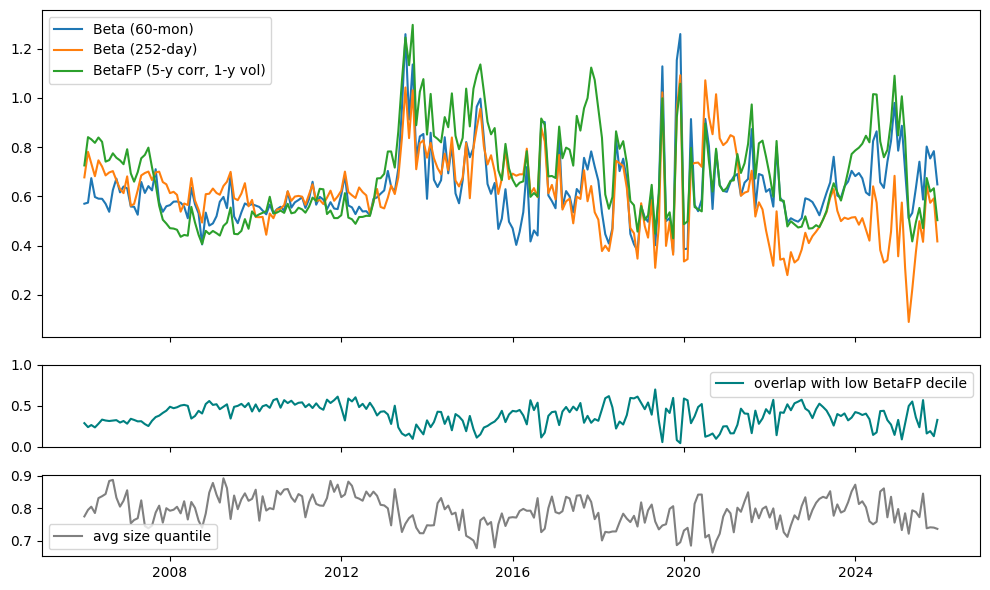

In [4]:
# Characteristics of stocks that contribute to Rg
rg_summary_last = rg_stocks_summary(port_wt_all)
rg_summary = rg_summary_last.sort_values("ym").copy()
rg_summary.index = pd.to_datetime(rg_summary["ym"].astype(str), format="%Y%m")
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [4, 1, 1]}, sharex=True)
ax1.plot(rg_summary["vw_Beta60m"], label="Beta (60-mon)")
ax1.plot(rg_summary["vw_Beta252d"], label="Beta (252-day)")
ax1.plot(rg_summary["vw_BetaFP"], label="BetaFP (5-y corr, 1-y vol)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", labelbottom=False)
ax1.legend()
ax2.plot(rg_summary["overlap_vs_bfp_d1"], label="overlap with low BetaFP decile", color="teal")
ax2.set_ylim(0, 1)
ax2.tick_params(axis="x", labelbottom=False)
ax2.legend()
ax3.plot(rg_summary["avg_size_quantile"], label="avg size quantile", color="gray")
ax3.legend()
plt.tight_layout()
plt.savefig(Path(plot_path) / "Rg_stocks_vwBeta.pdf", bbox_inches="tight", dpi=300)
plt.show()



Traditional Factors
                          Full                     Intraday                   Overnight
                    Ret     Vol    SR         Ret     Vol    SR         Ret     Vol    SR
----------------------------------------------------------------------------------------------
Mkt-RF                 9.63%   15.68%  0.61     2.09%   11.95%  0.18     8.20%   10.20%  0.80
LowBeta-RF             8.51%   11.11%  0.77     3.96%    9.06%  0.44     5.03%    7.33%  0.69
HighBeta-RF           12.03%   30.40%  0.40    -7.68%   24.20% -0.32    20.98%   18.24%  1.15

In-sample Decomposition
                          Full                     Intraday                   Overnight
                    Ret     Vol    SR         Ret     Vol    SR         Ret     Vol    SR
----------------------------------------------------------------------------------------------
Rg0-RF (from S&P 500)    10.87%   14.88%  0.73     7.67%   12.04%  0.64     3.71%    9.62%  0.39
Rg-RF                 13.02% 

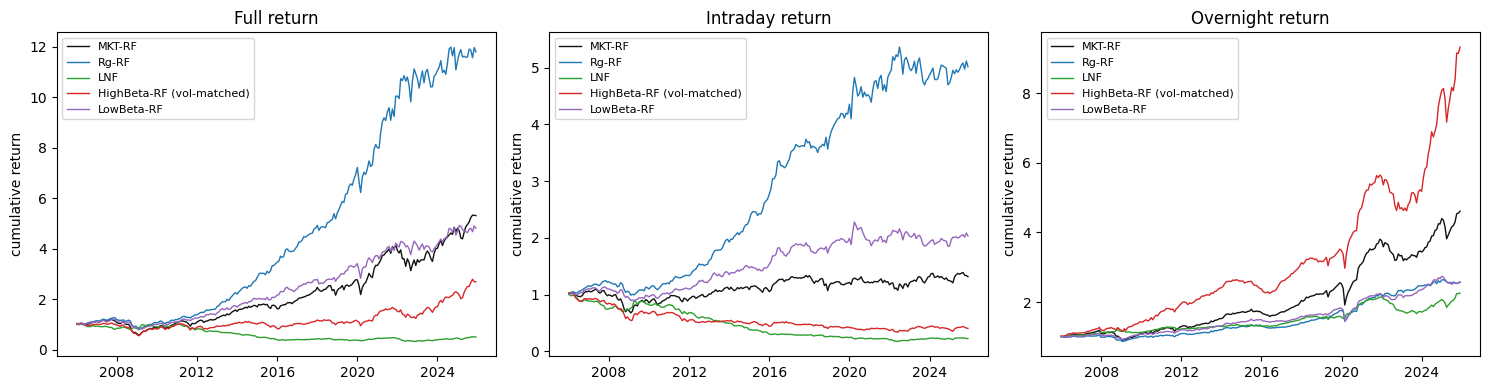

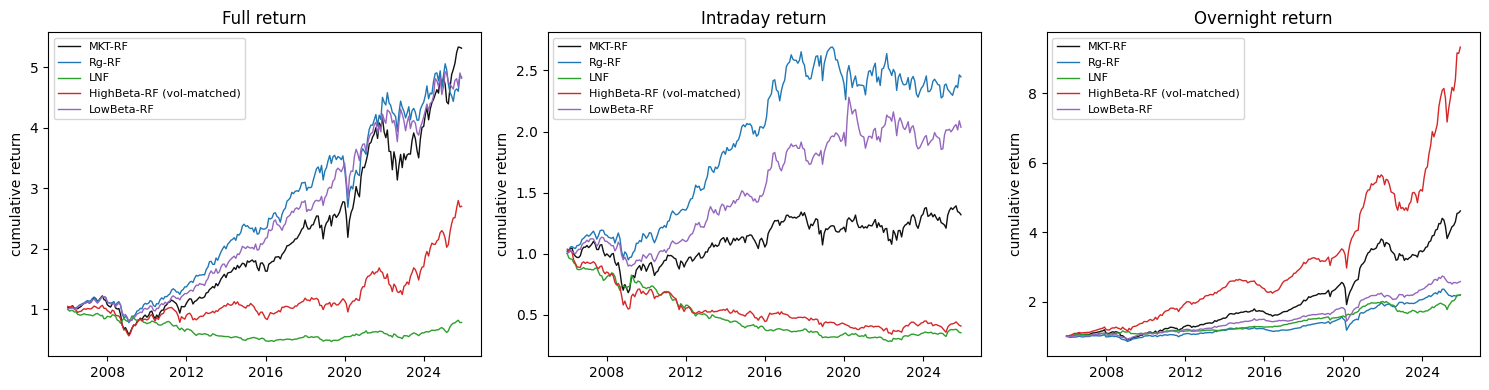

In [5]:
# Build LNF series, print stats, and plot cumulative returns
ret_ext, sub = summarize_and_plot_rg_lnf(port_ret_all)
perf_df = build_rg_lnf_perf_stats(sub)
print_latex_rg_lnf_perf_table(perf_df, latex_filename="rg_lnf_perf_table.tex")


In [6]:
# In-sample decomposition: conditional on the overlap with low BetaFP decile
overlap_ym = rg_summary_last[["ym", "overlap_vs_bfp_d1"]].copy()
overlap_med = pd.to_numeric(overlap_ym["overlap_vs_bfp_d1"], errors="coerce").median()
overlap_ym["Group"] = np.where(
    pd.to_numeric(overlap_ym["overlap_vs_bfp_d1"], errors="coerce") >= overlap_med,
    "High overlap",
    "Low overlap",
)

stats_df = build_conditional_stats(
    ret_ext=ret_ext,
    group_ym=overlap_ym[["ym", "Group"]],
    save_filename="overlap_conditional_stats_is.csv",
)



Conditional Stats (Full Excess Return, annualized)
  Months partitioned into {Low overlap, High overlap}. Each row reports that portfolio's annualized stats within the month subsample.
Portfolio        | Unconditional                 | Low overlap                   | High overlap                  | SR diff (Low overlap-High overlap)
                 |   mean(%)    vol(%)        SR |   mean(%)    vol(%)        SR |   mean(%)    vol(%)        SR |           diff    t-stat
-------------------------------------------------------------------------------------------------------------------------------------------
vwMKT-RF         |      9.63     15.68      0.61 |     16.83     12.65      1.33 |      2.42     18.03      0.13 |   1.20$^{***}$      2.64
LowBeta-RF       |      8.51     11.11      0.77 |     10.91     10.07      1.08 |      6.11     12.07      0.51 |           0.58      1.20
HighBeta-RF      |     12.03     30.40      0.40 |     22.36     26.39      0.85 |      1.69     33.79  

In [7]:
# Prepare monthly spanning regression dataset
g_spec = "Rg"
reg_df_g = prepare_insample_spanning_df(
    ret_ext=ret_ext,
    ff6_df=data["ff6"],
    g_port=g_spec,
    ret_col="ret_ex",
)
cov_order_factor = ["Intercept", "MKT_RF", "SMB", "HML", "RMW", "CMA", "MOM", "BAB"]
print(f"Results below using global factor specified as {g_spec}")

# Run factor span regressions for Rg and LNF

rg_lnf_factor_models = run_traditional_spanning(reg_df_g, f1="g_rf", f2="lnf")
display(stargazer_with_tstats(
    models=rg_lnf_factor_models,
    covariate_order=cov_order_factor,
    latex_filename="spanning_rg_lnf.tex",
))


Results below using global factor specified as Rg


In [8]:
# Run spanning regressions for ivol, coskew, and low_risk (CAPM and FF6)
# "ivol_21d": "[usa]_[ivol_capm_21d]_[monthly]_[vw_cap].csv",
# "ivol_252d": "[usa]_[ivol_capm_252d]_[monthly]_[vw_cap].csv",
# "low_risk": "[usa]_[low_risk]_[monthly]_[vw_cap].csv",

span_cols = ["ivol_21d", "ivol_252d", "low_risk"]

capm_compare_models = compare_capm_spanning(reg_df_g, span_cols=span_cols, pair_cols=("g_rf", "lnf"))
display(stargazer_with_tstats(
    models=capm_compare_models,
    covariate_order=["Intercept", "MKT_RF", "g_rf", "lnf"],
    latex_filename="spanning_low_risk.tex",
))

ff6_compare_models = compare_ff6_spanning(reg_df_g, span_cols=span_cols, pair_cols=("g_rf", "lnf"), add_bab=False)
display(stargazer_with_tstats(
    models=ff6_compare_models,
    covariate_order=["Intercept", "MKT_RF", "g_rf", "lnf", "SMB", "HML", "RMW", "CMA", "MOM", "BAB"],
    latex_filename="spanning_low_risk_ff6_bab.tex",
))



In [9]:
# Run spanning regressions for seasonality, momentum, and short_term_reversal (CAPM and FF6)
span_cols = ["seasonality", "momentum", "short_term_reversal"]

capm_compare_models = compare_capm_spanning(reg_df_g, span_cols=span_cols, pair_cols=("g_rf", "lnf"))
display(stargazer_with_tstats(
    models=capm_compare_models,
    covariate_order=["Intercept", "MKT_RF", "g_rf", "lnf"],
    latex_filename="spanning_other_themes_capm.tex",
))

